## Exploring the dataset

### Moving the train data to their corresponding folders

In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [3]:
train_df["Id"] = train_df["Id"].astype("str")
test_df["Id"] = test_df["Id"].astype("str")

In [4]:
train_labels_df = train_df.groupby(by="label")["Id"].apply(list).reset_index(name='Ids')
train_labels_df

,label,Ids
0,cup,"[4675, 2422, 8882, 8705, 5952, 1533, 4138, 108..."
1,fork,"[6446, 1228, 1279, 2112, 598, 5384, 8075, 2338..."
2,glass,"[560, 875, 6477, 2031, 3929, 4110, 138, 442, 2..."
3,knife,"[4617, 4257, 1717, 7042, 6826, 7406, 7541, 527..."
4,plate,"[8265, 4499, 2220, 3354, 241, 3201, 4853, 7395..."
5,spoon,"[4436, 8987, 7143, 5511, 6333, 5589, 9008, 679..."


In [5]:
import os
import shutil

In [9]:
for set_ in ["train", "val"]:
    os.mkdir(f"images/{set_}/")

for set_ in ["train", "val"]:
    for label in train_labels_df["label"].unique():
        os.mkdir(f"images/{set_}/{label}/")

In [16]:
# taking the train and validation sets
n_images = 5559

int(n_images * 0.2)

1111

In [35]:
dict_train = dict()
dict_val = dict()
for label in train_labels_df["label"].unique():
    ids = list(train_labels_df.loc[train_labels_df["label"] == label]["Ids"].values)[0]
    len_ = int(len(ids)*(1 - 0.2))

    ids_train = ids[: len_]
    ids_val = ids[len_: ]
    
    dict_train[label] = ids_train
    dict_val[label] = ids_val

In [36]:
dict_train.keys(), dict_val.keys()

(dict_keys(['cup', 'fork', 'glass', 'knife', 'plate', 'spoon']),
 dict_keys(['cup', 'fork', 'glass', 'knife', 'plate', 'spoon']))

In [37]:
len(dict_train["cup"])

908

In [38]:
classes = train_labels_df["label"].unique()
classes

array(['cup', 'fork', 'glass', 'knife', 'plate', 'spoon'], dtype=object)

In [40]:
# train set
source_folder = "images"
for label in classes:
    destination_folder = f"{source_folder}/train/{label}/"
    ids = dict_train[label]
    for file_id in ids:
        file_name = f"{file_id}.jpg"
        source = f"{source_folder}/{file_name}"
        destination = destination_folder + file_name
        # move only files
        if os.path.isfile(source):
            shutil.move(source, destination)
            #print('Moved:', file_name)
print("Status of the train set folder: Ok!")

Status of the train set folder: Ok!


In [41]:
# validation set
source_folder = "images"
for label in classes:
    destination_folder = f"{source_folder}/val/{label}/"
    ids = dict_val[label]
    for file_id in ids:
        file_name = f"{file_id}.jpg"
        source = f"{source_folder}/{file_name}"
        destination = destination_folder + file_name
        # move only files
        if os.path.isfile(source):
            shutil.move(source, destination)
            #print('Moved:', file_name)
print("Status of the validation set folder: Ok!")

Status of the validation set folder: Ok!


### Moving the test set

In [42]:
os.mkdir(f"images/test/")

In [43]:
files = os.listdir("images/")
files = [f for f in files if os.path.isfile("images/" + f)]

In [44]:
source_folder = "images"
destination_folder = f"{source_folder}/test/"
for file_name in files:
    source = f"{source_folder}/{file_name}"
    destination = destination_folder + file_name
    # move only files
    if os.path.isfile(source):
        shutil.move(source, destination)
            #print('Moved:', file_name)
print("Status of the test set folder: Ok!")

Status of the test set folder: Ok!


In [45]:
from tensorflow.keras.preprocessing.image import load_img

2022-12-20 21:58:39.862585: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-12-20 21:58:44.645232: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-12-20 21:58:44.645355: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2022-12-20 21:58:54.792735: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2022-

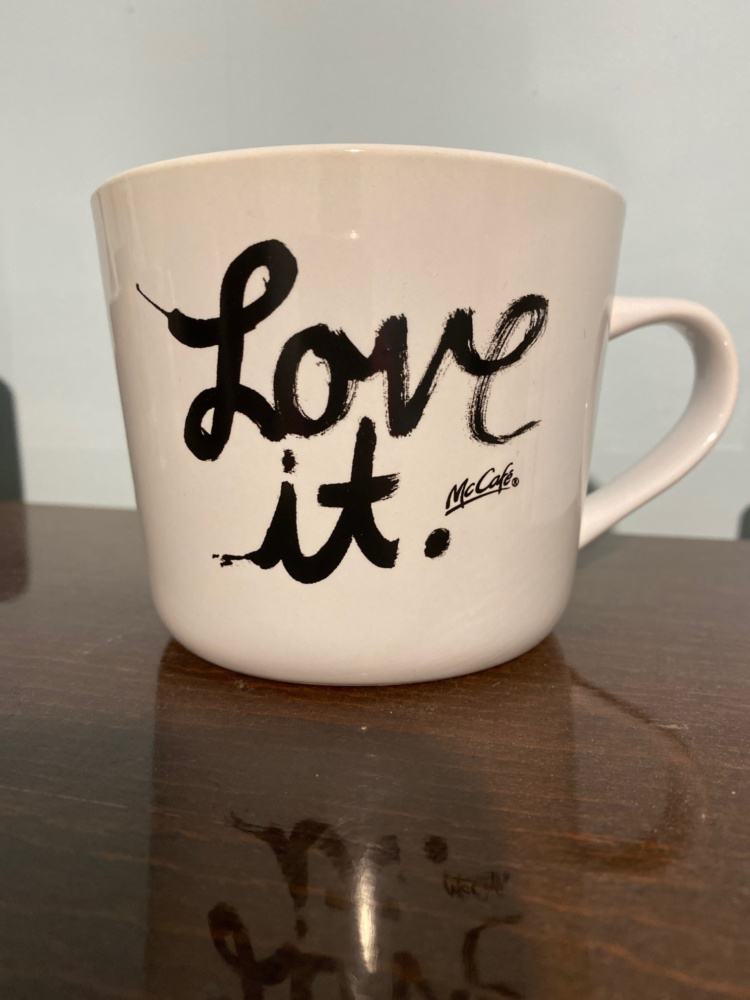

In [46]:
path = "./images/train/cup"
name = "1154.jpg"
fullname = f'{path}/{name}'
load_img(fullname)